# Week 1 - Assignment 1 (Agriculture Project: Predicting Probability of Flooding)
Cohort 3.0 — Data Science Track

**Task**: Frame an ML problem, explore data, build a leak-free preprocessing pipeline, and train a baseline regression model. 

**Deliverable**: A baseline model + short research brief.

In [4]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib, os, pathlib


**Import data**

In [5]:
DATA_PATH = "data/flood.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


## EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

In [7]:
df.isnull().sum()

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(50000, 21)

In [10]:
print("\nMissingness (%):")
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
display(missing_pct)


Missingness (%):


MonsoonIntensity                   0.0
TopographyDrainage                 0.0
RiverManagement                    0.0
Deforestation                      0.0
Urbanization                       0.0
ClimateChange                      0.0
DamsQuality                        0.0
Siltation                          0.0
AgriculturalPractices              0.0
Encroachments                      0.0
IneffectiveDisasterPreparedness    0.0
DrainageSystems                    0.0
CoastalVulnerability               0.0
Landslides                         0.0
Watersheds                         0.0
DeterioratingInfrastructure        0.0
PopulationScore                    0.0
WetlandLoss                        0.0
InadequatePlanning                 0.0
PoliticalFactors                   0.0
FloodProbability                   0.0
dtype: float64

In [11]:
display(df.describe(include='all'))

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,4.991480,4.984100,5.01594,5.008480,4.989060,4.988340,5.01536,4.988600,5.006120,5.006380,...,5.006060,4.999920,4.984220,4.97982,4.988200,4.984980,5.00512,4.994360,4.990520,0.499660
std,2.236834,2.246488,2.23131,2.222743,2.243159,2.226761,2.24500,2.232642,2.234588,2.241633,...,2.238107,2.247101,2.227741,2.23219,2.231134,2.238279,2.23176,2.230011,2.246075,0.050034
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.285000
25%,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,3.000000,0.465000
50%,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,0.500000
75%,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.00000,6.000000,6.000000,6.00000,6.000000,6.000000,0.535000
max,16.000000,18.000000,16.00000,17.000000,17.000000,17.000000,16.00000,16.000000,16.000000,18.000000,...,17.000000,17.000000,16.000000,16.00000,17.000000,19.000000,22.00000,16.000000,16.000000,0.725000


#### What is the distribution of flood probability?

Text(0.5, 1.0, 'Flood Probability')

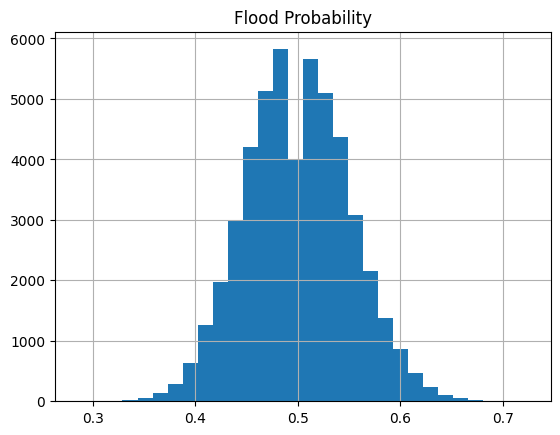

In [12]:
# Hist of target
plt.figure()
df['FloodProbability'].hist(bins=30)
plt.title('Flood Probability')

Text(0.5, 1.0, 'Monsoon Intensity vs Flood Probability')

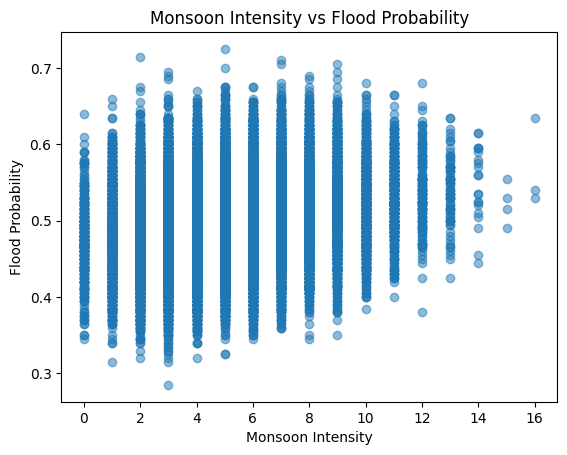

In [13]:
# Scatter: MonsoonIntensity vs FloodProbability
plt.figure()
plt.scatter(df['MonsoonIntensity'], df['FloodProbability'], alpha=0.5)
plt.xlabel('Monsoon Intensity'); plt.ylabel('Flood Probability'); plt.title('Monsoon Intensity vs Flood Probability')

In [14]:
#target variable
target = 'FloodProbability'

#features
features = [c for c in df.columns if c != target]
print(features)

['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']


In [15]:
X = df[features]
y = df[target]

In [16]:
X.head()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors
0,3,8,6,6,4,4,6,2,3,2,5,10,7,4,2,3,4,3,2,6
1,8,4,5,7,7,9,1,5,5,4,6,9,2,6,2,1,1,9,1,3
2,3,10,4,1,7,5,4,7,4,9,2,7,4,4,8,6,1,8,3,6
3,4,4,2,7,3,4,1,4,6,4,9,4,2,6,6,8,8,6,6,10
4,3,7,5,2,5,8,5,2,7,5,7,7,6,5,3,3,4,4,3,4


In [17]:
y.head()

0    0.450
1    0.475
2    0.515
3    0.520
4    0.475
Name: FloodProbability, dtype: float64

In [18]:
#splitting data into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
#seperating numerical from categorical
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
print(f"numerical: {numeric_features}")
#categorical_features = X.select_dtypes(include=['object']).columns.tolist()
#print (f"categorical: {categorical_features}")

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

'''categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])
'''
preprocess = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
#    ('cat', categorical_pipe, categorical_features)
])


numerical: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']


In [20]:
def evaluate(model, X_train, y_train, X_test, y_test, name='model'):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))  # <- compute manually
    r2 = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R^2={r2:.3f}")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

linreg = Pipeline([('prep', preprocess), ('model', LinearRegression())])
rf = Pipeline([('prep', preprocess), ('model', RandomForestRegressor(random_state=42, n_estimators=300))])

scores = []
scores.append(evaluate(linreg, X_train, y_train, X_test, y_test, 'LinearRegression'))
scores.append(evaluate(rf, X_train, y_train, X_test, y_test, 'RandomForestRegressor'))

pd.DataFrame(scores)

LinearRegression: MAE=0.000, RMSE=0.000, R^2=1.000
RandomForestRegressor: MAE=0.020, RMSE=0.026, R^2=0.735


,model,MAE,RMSE,R2
0,LinearRegression,3.312239e-16,4.190162e-16,1.00000
1,RandomForestRegressor,2.028142e-02,2.570460e-02,0.73471


In [21]:
print('FloodProbability' in X_train.columns)

False


In [22]:
# Check that the target column is not in X_train or X_test
'FloodProbability' in X_train.columns, 'FloodProbability' in X_test.columns

(False, False)

In [23]:
# Check overlap between X_train and X_test
len(pd.merge(X_train, X_test, how='inner'))

0

In [24]:
corrs = df.corr(numeric_only=True)['FloodProbability'].sort_values(ascending=False)
print(corrs)

FloodProbability                   1.000000
DeterioratingInfrastructure        0.229444
TopographyDrainage                 0.229414
RiverManagement                    0.228917
Watersheds                         0.228152
DamsQuality                        0.227467
PopulationScore                    0.226928
Siltation                          0.226544
IneffectiveDisasterPreparedness    0.225126
PoliticalFactors                   0.225009
MonsoonIntensity                   0.224081
WetlandLoss                        0.223732
InadequatePlanning                 0.223329
Landslides                         0.222991
AgriculturalPractices              0.221846
ClimateChange                      0.220986
Urbanization                       0.220867
Deforestation                      0.220237
Encroachments                      0.218259
DrainageSystems                    0.217895
CoastalVulnerability               0.215187
Name: FloodProbability, dtype: float64


In [25]:
y_train.describe(), y_test.describe()

(count    40000.000000
 mean         0.499519
 std          0.050065
 min          0.285000
 25%          0.465000
 50%          0.500000
 75%          0.535000
 max          0.725000
 Name: FloodProbability, dtype: float64,
 count    10000.000000
 mean         0.500227
 std          0.049908
 min          0.315000
 25%          0.465000
 50%          0.500000
 75%          0.535000
 max          0.705000
 Name: FloodProbability, dtype: float64)

In [26]:
from numpy.linalg import matrix_rank

Xn = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

# Compute rank of X and [X|y]
rank_X = matrix_rank(Xn)
rank_Xy = matrix_rank(np.c_[Xn, y])

print("Rank of X:", rank_X)
print("Rank of [X|y]:", rank_Xy)

Rank of X: 20
Rank of [X|y]: 20


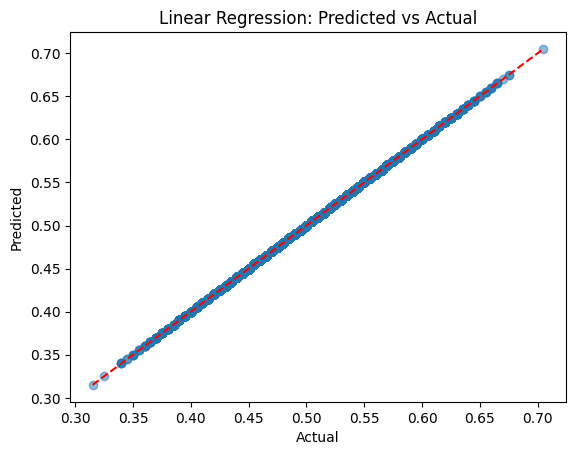

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, linreg.predict(X_test), alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()
